# 05 - Forecasting Results & Visualisations

Loads the prediction CSVs from `results/predictions/` and the 2024 ground truth,
then produces all plots needed for the report and presentation.

**Run `04_Forecasting.ipynb` first** to generate the prediction CSVs.

## Section 0 - Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error

from src.utils.config import (
    PREDICTIONS_DIR, FIGURES_DIR, DIAGNOSTICS_DIR, RESULTS_DIR,
    LAG_FEATURES, ROLLING_WINDOWS,
)
from src.utils.data_loader import load_test_data

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

METHOD_LABELS = {
    'feature_ward': 'Feature+Ward (cluster)',
    'kshape':       'k-Shape (cluster)',
    'global':       'Global baseline',
}
METHOD_COLORS = {
    'feature_ward': '#1B6CA8',
    'kshape':       '#F59E0B',
    'global':       '#6B7280',
}
CLUSTER_COLORS = ['#1B6CA8', '#2A9FD6', '#56CFE1', '#F59E0B', '#E05252', '#6B7280']

print('Setup complete.')
print(f'Figures will be saved to: {FIGURES_DIR}')

Setup complete.
Figures will be saved to: /home/hemali/rdkd/RDK Project (4)/results/figures


## Section 1 - Load Predictions & Ground Truth

In [2]:
# Load 2024 ground truth
test_wide = load_test_data()
print(f'Test data (2024): {test_wide.shape}')

# Melt ground truth to long format
actuals = test_wide.reset_index().melt(
    id_vars=test_wide.index.name or 'household_id',
    var_name='date', value_name='actual'
)
actuals.columns = ['household_id', 'date', 'actual']
actuals['date'] = pd.to_datetime(actuals['date'])
print(f'Actuals long:     {actuals.shape}')

Test data (2024): (17547, 366)
Actuals long:     (6422202, 3)


In [3]:
# Load prediction CSVs and join actuals
preds = {}
for method in ['feature_ward', 'kshape', 'global']:
    p = PREDICTIONS_DIR / f'predictions_2024_{method}.csv'
    if not p.exists():
        print(f'  MISSING: {p.name} - run 04_Forecasting.ipynb first')
        continue
    df = pd.read_csv(p, parse_dates=['date'])
    df = df.merge(actuals, on=['household_id', 'date'], how='left')
    preds[method] = df
    n_hh   = df['household_id'].nunique()
    n_days = df.groupby('household_id').size()
    print(f'  {method:<15}: {n_hh:,} households | {n_days.min()}–{n_days.max()} days/hh')

# Sanity check: all should have 17,547 households x 366 days
for method, df in preds.items():
    assert df['household_id'].nunique() == test_wide.shape[0], \
        f'{method}: household count mismatch'
    assert df.groupby('household_id').size().eq(366).all(), \
        f'{method}: not all households have 366 days'
print('\n✓ All prediction files validated: 17,547 households × 366 days')

  feature_ward   : 17,547 households | 366–366 days/hh
  kshape         : 17,547 households | 366–366 days/hh
  global         : 17,547 households | 366–366 days/hh

✓ All prediction files validated: 17,547 households × 366 days


## Section 2 - Per-Household MAE

The primary evaluation metric: MAE over 366 days per household, averaged across all households.

In [4]:
hh_maes = {}
summary_rows = []

for method, df in preds.items():
    df_clean = df.dropna(subset=['actual', 'predicted'])
    hh_mae = (
        df_clean.groupby('household_id')
        .apply(lambda g: mean_absolute_error(g['actual'], g['predicted']))
        .reset_index(name='mae')
    )
    hh_maes[method] = hh_mae
    summary_rows.append({
        'Method':         METHOD_LABELS[method],
        'Avg HH MAE':     round(hh_mae['mae'].mean(), 4),
        'Median HH MAE':  round(hh_mae['mae'].median(), 4),
        'Std HH MAE':     round(hh_mae['mae'].std(), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Method')
print('=== PRIMARY EVALUATION RESULTS ===')
display(summary_df)

=== PRIMARY EVALUATION RESULTS ===


,Avg HH MAE,Median HH MAE,Std HH MAE
Method,,,
Feature+Ward (cluster),2.0965,1.5788,2.3569
k-Shape (cluster),2.1058,1.5781,2.3923
Global baseline,2.1076,1.5770,2.4187


## Section 3 - Method Comparison Bar Chart

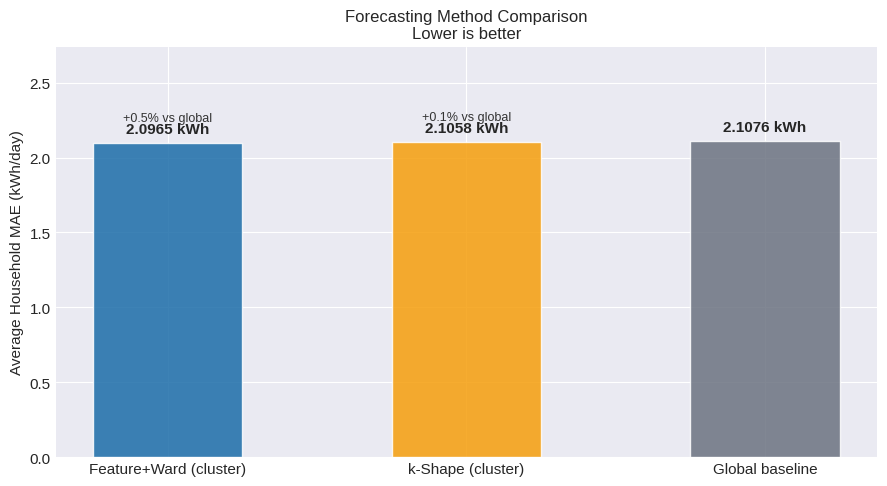

Saved: forecast_method_comparison.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

names    = list(hh_maes.keys())
avg_maes = [hh_maes[m]['mae'].mean() for m in names]
colors   = [METHOD_COLORS[m] for m in names]

bars = ax.bar(
    [METHOD_LABELS[m] for m in names], avg_maes,
    color=colors, alpha=0.85, edgecolor='white', width=0.5
)
ax.bar_label(bars, labels=[f'{v:.4f} kWh' for v in avg_maes],
             padding=5, fontsize=11, fontweight='bold')

# Annotate % improvement over global
if 'global' in hh_maes:
    base = hh_maes['global']['mae'].mean()
    for i, (m, mae) in enumerate(zip(names, avg_maes)):
        if m != 'global':
            pct = (base - mae) / base * 100
            ax.text(i, mae + max(avg_maes) * 0.07,
                    f'{pct:+.1f}% vs global',
                    ha='center', fontsize=9, color='#333')

ax.set_ylabel('Average Household MAE (kWh/day)', fontsize=11)
ax.set_title('Forecasting Method Comparison\nLower is better', fontsize=12)
ax.set_ylim(0, max(avg_maes) * 1.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'forecast_method_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: forecast_method_comparison.png')

## Section 4 - Household MAE Distribution

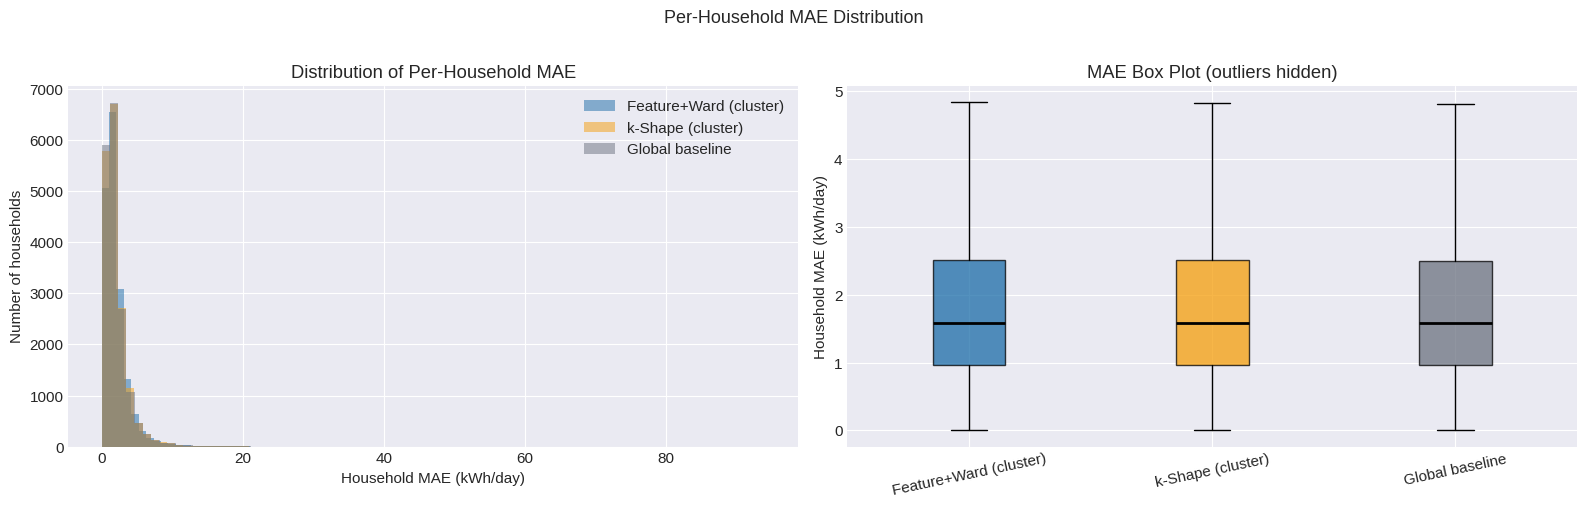

Saved: forecast_mae_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
for method, hm in hh_maes.items():
    axes[0].hist(hm['mae'], bins=80, alpha=0.5,
                 label=METHOD_LABELS[method],
                 color=METHOD_COLORS[method], edgecolor='none')
axes[0].set_xlabel('Household MAE (kWh/day)')
axes[0].set_ylabel('Number of households')
axes[0].set_title('Distribution of Per-Household MAE')
axes[0].legend()

# Box plot
data_b   = [hh_maes[m]['mae'].values for m in preds]
labels_b = [METHOD_LABELS[m] for m in preds]
bp = axes[1].boxplot(data_b, labels=labels_b, patch_artist=True,
                     showfliers=False,
                     medianprops=dict(color='black', linewidth=2))
for patch, m in zip(bp['boxes'], preds):
    patch.set_facecolor(METHOD_COLORS[m])
    patch.set_alpha(0.75)
axes[1].set_ylabel('Household MAE (kWh/day)')
axes[1].set_title('MAE Box Plot (outliers hidden)')
axes[1].tick_params(axis='x', rotation=12)

plt.suptitle('Per-Household MAE Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'forecast_mae_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: forecast_mae_distribution.png')

## Section 5 - Actual vs Predicted: Daily Mean per Cluster

For each cluster, plots the mean actual and mean predicted consumption across
all households in that cluster, day by day over 2024.
Shows whether the model captures seasonal shape correctly.

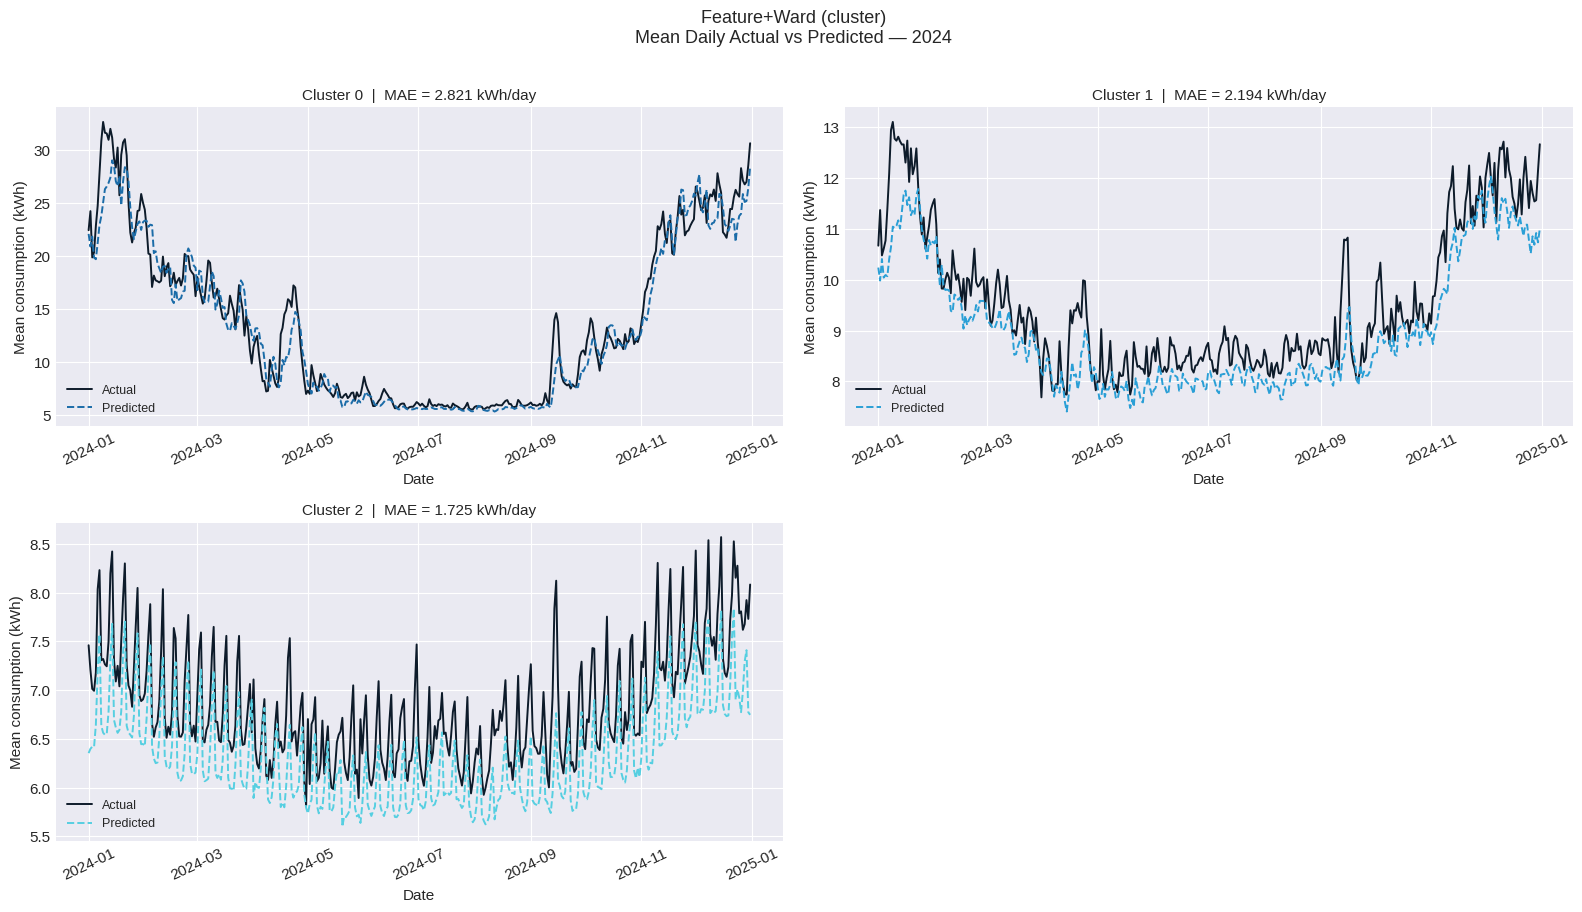

Saved: forecast_actual_vs_predicted_feature_ward.png


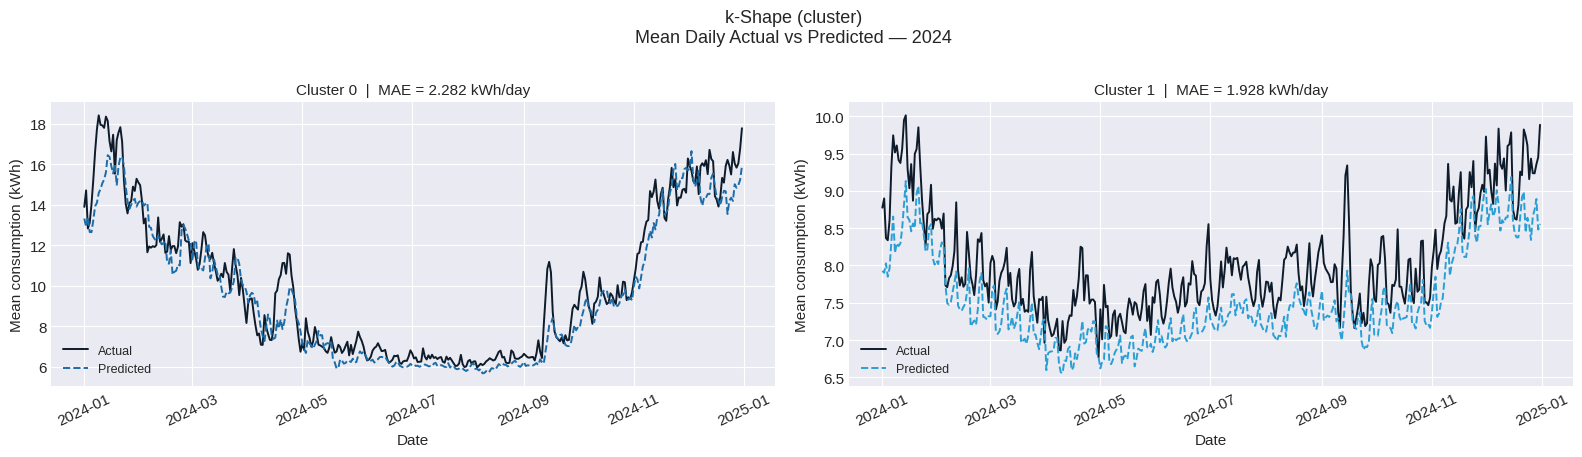

Saved: forecast_actual_vs_predicted_kshape.png


In [7]:
for method in ['feature_ward', 'kshape']:
    if method not in preds:
        continue
    df      = preds[method].dropna(subset=['actual', 'predicted'])
    reg_df  = df[df['cluster'] >= 0]
    labels  = sorted(reg_df['cluster'].unique().tolist())
    n       = len(labels)
    ncols   = 2
    nrows   = (n + 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, label in enumerate(labels):
        sub   = reg_df[reg_df['cluster'] == label]
        daily = sub.groupby('date')[['actual', 'predicted']].mean()
        mae_c = mean_absolute_error(sub['actual'], sub['predicted'])

        ax = axes[i]
        ax.plot(daily.index, daily['actual'],
                lw=1.4, label='Actual', color='#0D1B2A')
        ax.plot(daily.index, daily['predicted'],
                lw=1.4, linestyle='--', label='Predicted',
                color=CLUSTER_COLORS[i % len(CLUSTER_COLORS)])
        ax.set_title(f'Cluster {label}  |  MAE = {mae_c:.3f} kWh/day', fontsize=11)
        ax.set_xlabel('Date')
        ax.set_ylabel('Mean consumption (kWh)')
        ax.legend(fontsize=9)
        ax.tick_params(axis='x', rotation=25)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'{METHOD_LABELS[method]}\n'
                 f'Mean Daily Actual vs Predicted - 2024',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    fname = f'forecast_actual_vs_predicted_{method}.png'
    plt.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## Section 6 - Per-Cluster MAE

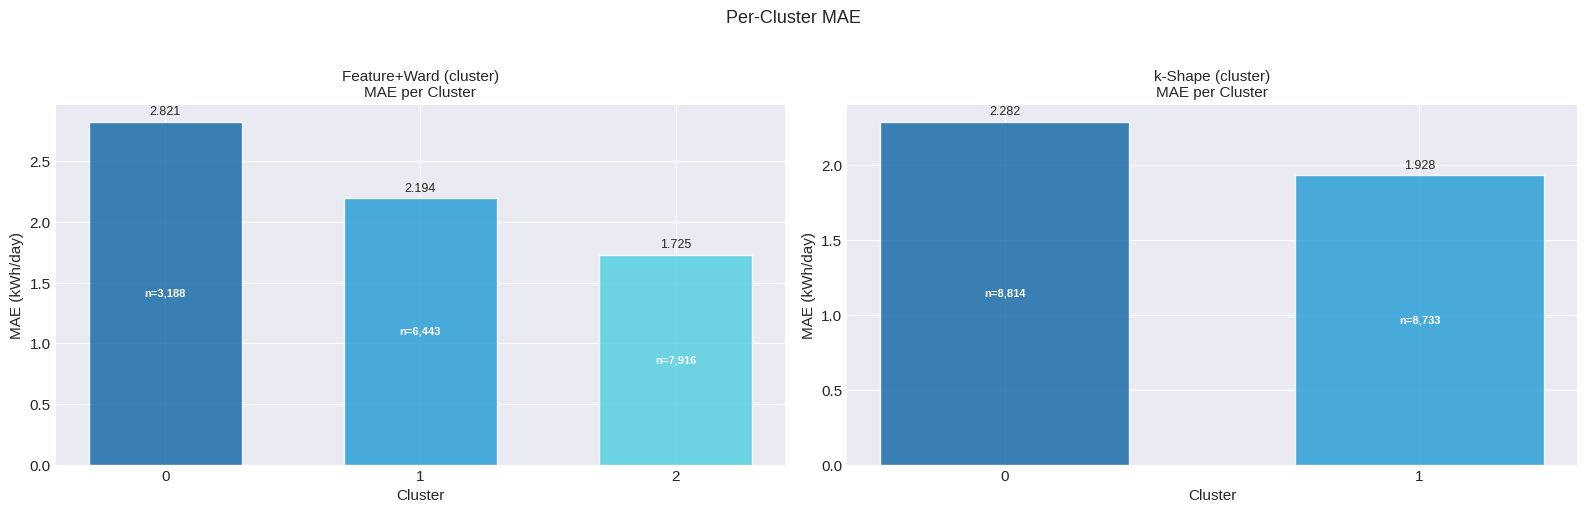

Saved: forecast_per_cluster_mae.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, method in zip(axes, ['feature_ward', 'kshape']):
    if method not in preds:
        ax.set_title(f'{method} not available')
        continue
    df     = preds[method].dropna(subset=['actual', 'predicted'])
    reg_df = df[df['cluster'] >= 0]
    labels = sorted(reg_df['cluster'].unique().tolist())

    cluster_maes = [
        mean_absolute_error(
            reg_df[reg_df['cluster'] == l]['actual'],
            reg_df[reg_df['cluster'] == l]['predicted']
        )
        for l in labels
    ]
    n_hhs = [reg_df[reg_df['cluster'] == l]['household_id'].nunique() for l in labels]

    bars = ax.bar([str(l) for l in labels], cluster_maes,
                  color=CLUSTER_COLORS[:len(labels)], alpha=0.85,
                  edgecolor='white', width=0.6)
    ax.bar_label(bars, labels=[f'{v:.3f}' for v in cluster_maes],
                 padding=3, fontsize=9)

    # Annotate n households
    for j, (bar, n) in enumerate(zip(bars, n_hhs)):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 0.5,
                f'n={n:,}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

    ax.set_title(f'{METHOD_LABELS[method]}\nMAE per Cluster', fontsize=11)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('MAE (kWh/day)')

plt.suptitle('Per-Cluster MAE', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'forecast_per_cluster_mae.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: forecast_per_cluster_mae.png')

## Section 7 - Seasonal Error Pattern (Monthly MAE)

Shows which months are hardest to forecast.
Spikes in winter or summer reveal where the model struggles.

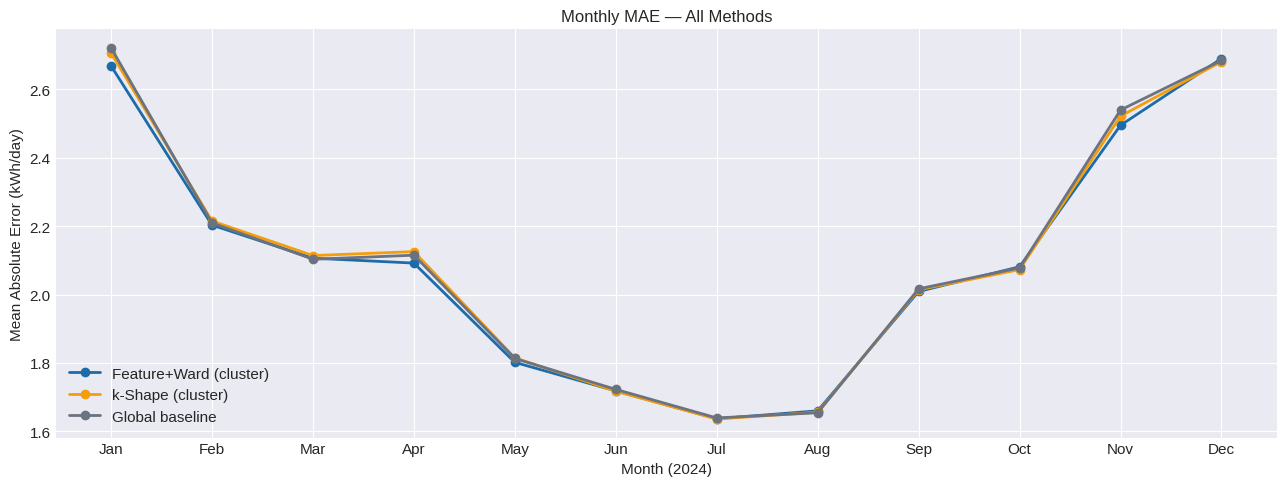

Saved: forecast_monthly_mae.png


In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for method, df in preds.items():
    df = df.dropna(subset=['actual', 'predicted']).copy()
    df['month']   = df['date'].dt.month
    df['abs_err'] = (df['actual'] - df['predicted']).abs()
    monthly = df.groupby('month')['abs_err'].mean()
    ax.plot(monthly.index, monthly.values,
            marker='o', lw=2,
            label=METHOD_LABELS[method],
            color=METHOD_COLORS[method])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month (2024)')
ax.set_ylabel('Mean Absolute Error (kWh/day)')
ax.set_title('Monthly MAE - All Methods', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'forecast_monthly_mae.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: forecast_monthly_mae.png')

## Section 8 - Residual Distributions

`actual − predicted`. Ideal: symmetric bell centred at 0.
A shift from 0 means systematic over- or under-prediction.

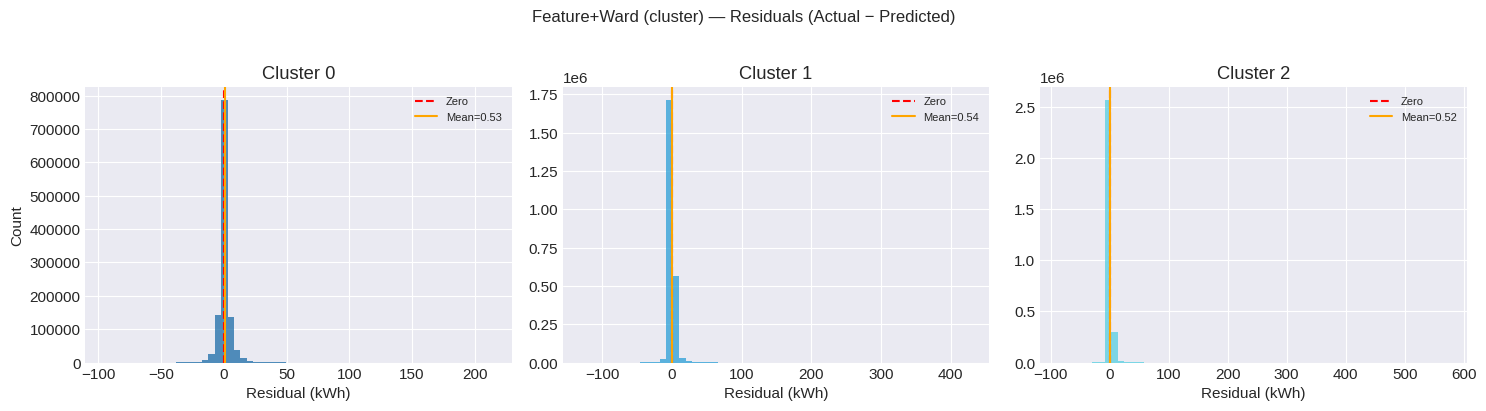

Saved: forecast_residuals_feature_ward.png


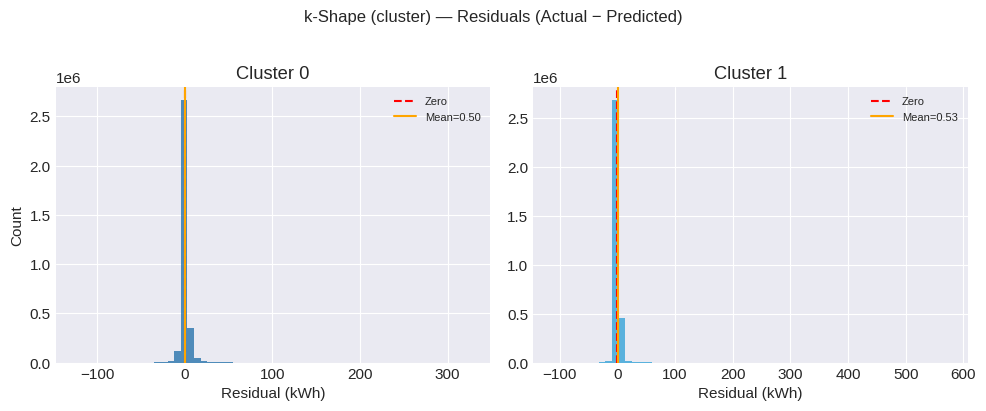

Saved: forecast_residuals_kshape.png


In [10]:
for method in ['feature_ward', 'kshape']:
    if method not in preds:
        continue
    df     = preds[method].dropna(subset=['actual', 'predicted']).copy()
    df['residual'] = df['actual'] - df['predicted']
    reg_df = df[df['cluster'] >= 0]
    labels = sorted(reg_df['cluster'].unique().tolist())

    fig, axes = plt.subplots(1, len(labels),
                             figsize=(5 * len(labels), 4))
    if len(labels) == 1:
        axes = [axes]

    for ax, label in zip(axes, labels):
        resid = reg_df[reg_df['cluster'] == label]['residual'].dropna()
        ax.hist(resid, bins=60, alpha=0.75,
                color=CLUSTER_COLORS[labels.index(label) % len(CLUSTER_COLORS)],
                edgecolor='none')
        ax.axvline(0, color='red', linestyle='--', lw=1.5, label='Zero')
        ax.axvline(resid.mean(), color='orange', lw=1.5,
                   label=f'Mean={resid.mean():.2f}')
        ax.set_title(f'Cluster {label}')
        ax.set_xlabel('Residual (kWh)')
        ax.legend(fontsize=8)

    axes[0].set_ylabel('Count')
    plt.suptitle(f'{METHOD_LABELS[method]} - Residuals (Actual − Predicted)',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    fname = f'forecast_residuals_{method}.png'
    plt.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## Section 9 - Feature Importance

Loaded from saved model `.pkl` files.
Shows what the model relies on most - useful for explaining the approach.

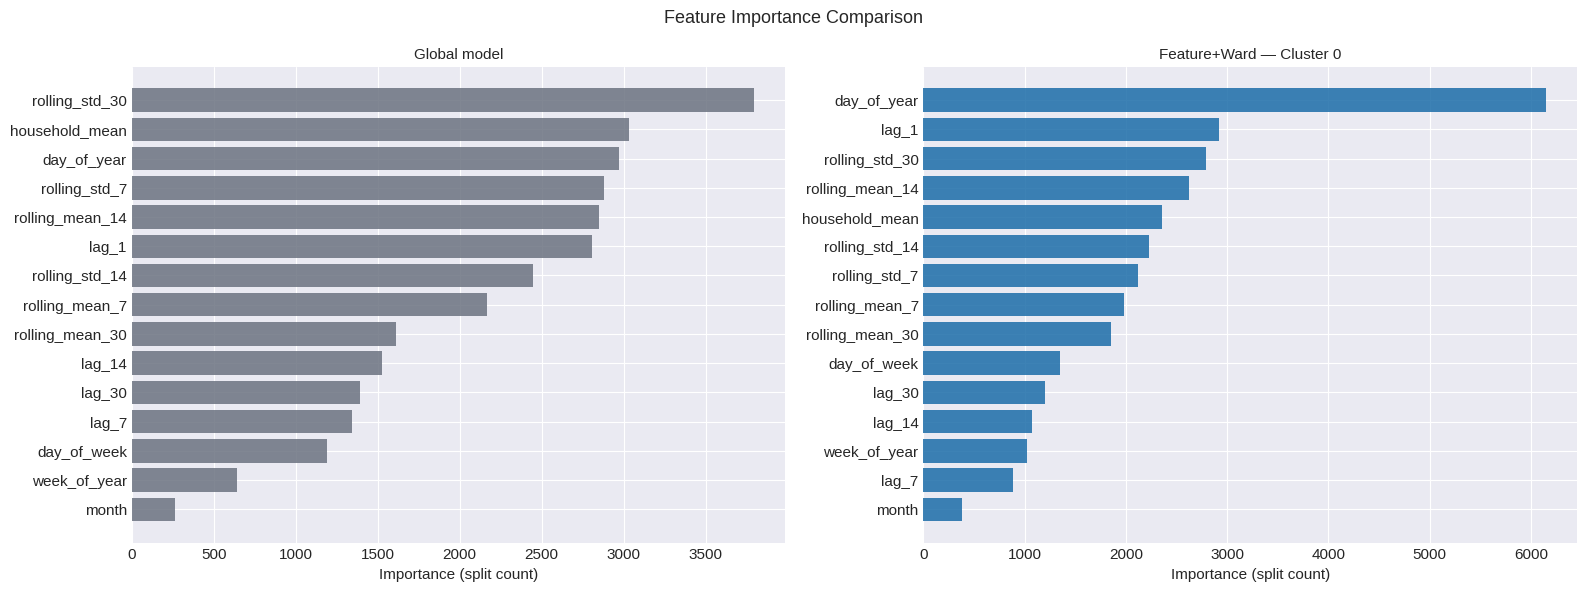

Saved: forecast_feature_importance.png


In [11]:
import pickle

feature_cols = (
    [f'lag_{l}' for l in LAG_FEATURES]
    + [f'rolling_mean_{w}' for w in ROLLING_WINDOWS]
    + [f'rolling_std_{w}'  for w in ROLLING_WINDOWS]
    + ['day_of_week', 'month', 'day_of_year',
       'is_weekend', 'week_of_year', 'household_mean']
)

def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def plot_importance(model, cols, title, ax, color, top_n=15):
    imp = pd.DataFrame({'feature': cols,
                        'importance': model.feature_importances_})
    imp = imp.sort_values('importance', ascending=False).head(top_n)
    ax.barh(imp['feature'][::-1], imp['importance'][::-1],
            color=color, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Importance (split count)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Global model
gl_path = RESULTS_DIR / 'models' / 'global' / 'lgbm_global.pkl'
if gl_path.exists():
    plot_importance(load_pkl(gl_path), feature_cols,
                   'Global model', axes[0], METHOD_COLORS['global'])
else:
    axes[0].set_title('Global model not found - run 04 first')

# Feature-ward cluster 0
fw_path = RESULTS_DIR / 'models' / 'feature_ward' / 'lgbm_cluster_0.pkl'
if fw_path.exists():
    plot_importance(load_pkl(fw_path), feature_cols,
                   'Feature+Ward - Cluster 0', axes[1], METHOD_COLORS['feature_ward'])
else:
    axes[1].set_title('Feature+Ward cluster 0 not found - run 04 first')

plt.suptitle('Feature Importance Comparison', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'forecast_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: forecast_feature_importance.png')

## Section 10 - Example Households: Best and Worst Predictions

Concrete examples of what good and bad forecasts look like for individual households.
Useful for the presentation.

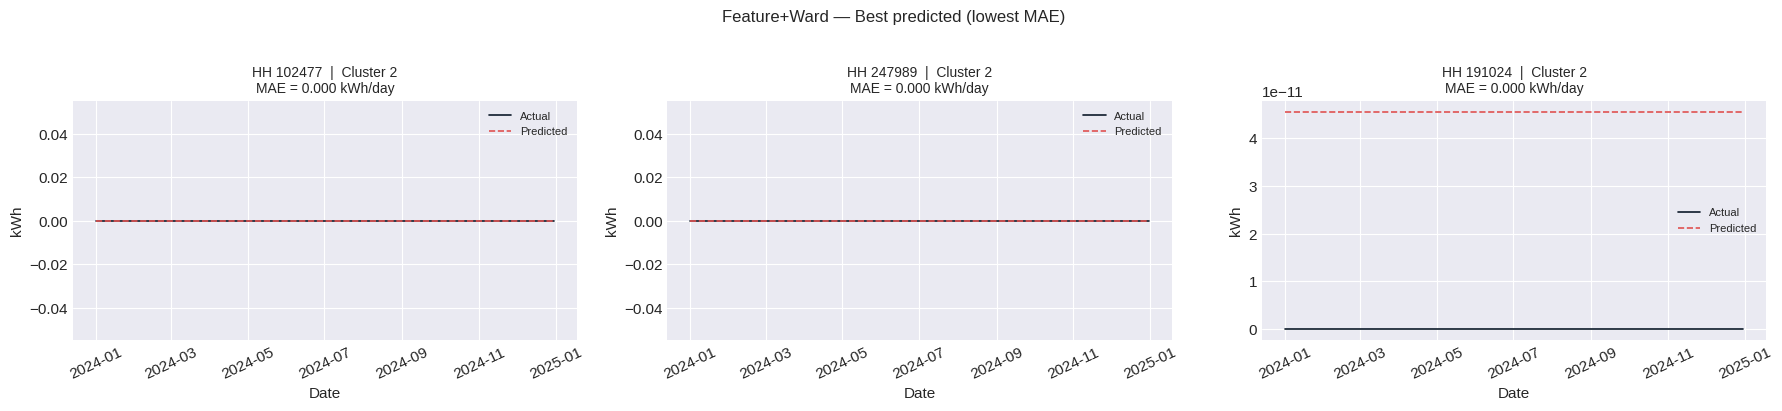

Saved: forecast_examples_best.png


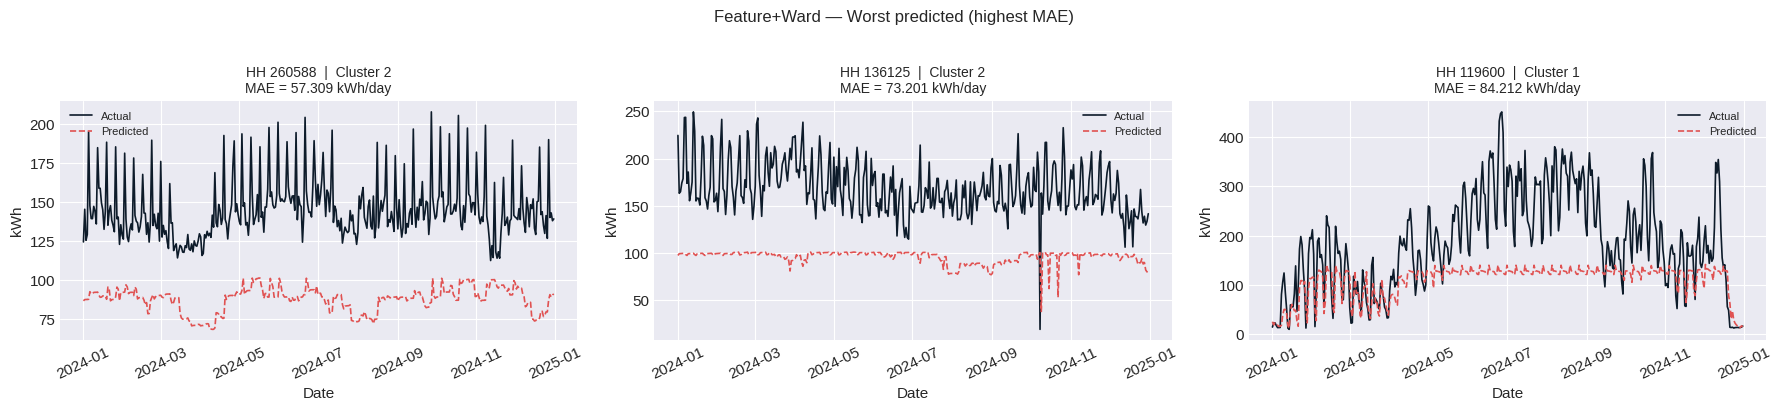

Saved: forecast_examples_worst.png


In [12]:
if 'feature_ward' in preds:
    df = preds['feature_ward'].dropna(subset=['actual', 'predicted'])
    hh_mae = (
        df.groupby('household_id')
        .apply(lambda g: mean_absolute_error(g['actual'], g['predicted']))
        .reset_index(name='mae')
        .sort_values('mae')
    )

    best_hhs  = hh_mae.head(3)['household_id'].tolist()
    worst_hhs = hh_mae.tail(3)['household_id'].tolist()

    for group_label, hh_ids in [
        ('Best predicted (lowest MAE)', best_hhs),
        ('Worst predicted (highest MAE)', worst_hhs),
    ]:
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        for ax, hh_id in zip(axes, hh_ids):
            sub    = df[df['household_id'] == hh_id].sort_values('date')
            hh_mae_val = mean_absolute_error(sub['actual'], sub['predicted'])
            cluster_id = sub['cluster'].iloc[0]
            ax.plot(sub['date'], sub['actual'],
                    lw=1.2, label='Actual', color='#0D1B2A')
            ax.plot(sub['date'], sub['predicted'],
                    lw=1.2, linestyle='--', label='Predicted',
                    color='#E05252')
            ax.set_title(f'HH {hh_id}  |  Cluster {cluster_id}\n'
                         f'MAE = {hh_mae_val:.3f} kWh/day', fontsize=10)
            ax.set_xlabel('Date')
            ax.set_ylabel('kWh')
            ax.legend(fontsize=8)
            ax.tick_params(axis='x', rotation=25)
        plt.suptitle(f'Feature+Ward - {group_label}', fontsize=12, y=1.02)
        plt.tight_layout()
        fname = f"forecast_examples_{'best' if 'Best' in group_label else 'worst'}.png"
        plt.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

## Section 11 - Summary

In [13]:
print('=== FORECASTING RESULTS SUMMARY ===')
print()
display(summary_df)

print('\nFigures saved:')
for f in sorted(FIGURES_DIR.glob('forecast_*.png')):
    print(f'  {f.name}')

=== FORECASTING RESULTS SUMMARY ===



,Avg HH MAE,Median HH MAE,Std HH MAE
Method,,,
Feature+Ward (cluster),2.0965,1.5788,2.3569
k-Shape (cluster),2.1058,1.5781,2.3923
Global baseline,2.1076,1.5770,2.4187



Figures saved:
  forecast_actual_vs_predicted_feature_ward.png
  forecast_actual_vs_predicted_kshape.png
  forecast_examples_best.png
  forecast_examples_worst.png
  forecast_feature_importance.png
  forecast_mae_distribution.png
  forecast_method_comparison.png
  forecast_monthly_mae.png
  forecast_per_cluster_mae.png
  forecast_residuals_feature_ward.png
  forecast_residuals_kshape.png
